# Credit Card Fraud Detection - EDA & Preprocessing Pipeline

This notebook covers the database data retrieval, exploratory data analysis (EDA), data quality assessment, and a reproducible preprocessing pipeline.

### Project Details
- **Dataset**: Kaggle Credit Card Fraud Detection (European cardholder transactions in Sept 2013).
- **Shape**: 284,807 rows, 31 columns.
- **Target**: `Class` (0 = Legitimate, 1 = Fraud).
- **Features**: `Time` (seconds elapsed), `Amount` (transaction size), and `V1`-`V28` (anonymized PCA components).
- **Challenge**: Severe class imbalance (only 492 fraud cases, or 0.173%).

## 1. Setup & Environment
Importing analysis libraries and setting up database engine using environment variables.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# Plotting configuration
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

In [2]:
load_dotenv()
db_url = os.getenv('DATABASE_URL')

# Create database engine
engine = create_engine(db_url)

# Test the connection
with engine.connect() as conn:
    conn.execute(text('SELECT 1;'))
    print('Database connection successful.')

Database connection successful.


## 2. Load Dataset
Retrieving all transaction records from the PostgreSQL table.

In [3]:
query = 'SELECT * FROM creditcard_transactions;'
df = pd.read_sql(query, engine)
print(f'Dataset successfully loaded into a pandas DataFrame from PostgreSQL.')
print(f'Shape of the dataset: {df.shape}')


Dataset successfully loaded into a pandas DataFrame from PostgreSQL.
Shape of the dataset: (284807, 31)


In [4]:
print('First 5 rows of the dataset:')
df.head()


First 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print('Last 5 rows of the dataset:')
df.tail()


Last 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## 3. Dataset Overview
Inspecting column data types, shapes, and general statistics.

In [6]:
print('--- Dataset Info ---')
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

In [7]:
print('--- Summary Statistics ---')
df.describe()


--- Summary Statistics ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.205498e-16,-2.406306e-15,...,1.656562e-16,-3.568593e-16,2.610582e-16,4.473066e-15,5.213180e-16,1.683537e-15,-3.659966e-16,-1.223710e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Observations:
- **V1 - V28**: These are PCA features with small standard deviations centered around 0. This is typical for principal components.
- **Amount**: Highly right-skewed. The median transaction amount is only $22.00, while the mean is $88.35, and the maximum is $25,691.16.
- **Time**: Spans from 0 to 172,792 seconds, which represents exactly 48 hours of time elapsed from the first transaction.
- **Class**: Mean is 0.0017, confirming the severe class imbalance (0.173% positive rate).

## 4. Data Quality Assessment
Auditing dataset for missing values, duplicates, and anomalous entries.

In [8]:
# Check for missing values
null_counts = df.isnull().sum()
print('Missing Values per column:')
print(null_counts[null_counts > 0] if (null_counts > 0).any() else 'No missing values found!')


Missing Values per column:
No missing values found!


In [9]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
duplicate_pct = (duplicate_count / len(df)) * 100
print(f'Duplicate Rows: {duplicate_count}')
print(f'Duplicate Percentage: {duplicate_pct:.4f}%')


Duplicate Rows: 1081
Duplicate Percentage: 0.3796%


In [10]:
# Identify duplicates within Class=0 and Class=1
print('Duplicates in Legitimate transactions (Class 0):', df[df['Class'] == 0].duplicated().sum())
print('Duplicates in Fraudulent transactions (Class 1):', df[df['Class'] == 1].duplicated().sum())


Duplicates in Legitimate transactions (Class 0): 1062
Duplicates in Fraudulent transactions (Class 1): 19


In [11]:
# Check for negative or anomalous amounts
negative_amounts = (df['Amount'] < 0).sum()
print(f'Negative Amounts: {negative_amounts}')
zero_amounts = (df['Amount'] == 0).sum()
print(f'Zero-value transactions: {zero_amounts} ({zero_amounts/len(df)*100:.4f}%)')


Negative Amounts: 0
Zero-value transactions: 1825 (0.6408%)


### Data Quality Decisions:

- **Nulls**: 0 missing values across all columns. The dataset is complete, but we will keep a median imputer in the preprocessing pipeline as a safeguard for production.
- **Duplicates**: Found 1,081 duplicate rows (0.38%). Most duplicates are legitimate transactions, but 19 are in the fraud class. Although duplicate charges can occur, we recommend dropping duplicates prior to model training to prevent train-test data leakage.
- **Anomalous Values**: No negative transaction amounts. 1,825 zero-amount transactions exist, representing validation checks. We will retain these since they carry valid PCA features.
- **Target Leakage**: No columns contain posterior information or proxies of the target class. Features are safe to use for modeling.

## 5. Class Imbalance Analysis
Examining target variable distribution.

In [12]:
# Compute Class counts and ratios
class_counts = df['Class'].value_counts()
class_pcts = df['Class'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(f'Legitimate (Class 0): {class_counts[0]} ({class_pcts[0]:.4f}%)')
print(f'Fraudulent (Class 1): {class_counts[1]} ({class_pcts[1]:.4f}%)')
print(f'Imbalance Ratio (Legitimate / Fraudulent): {class_counts[0] / class_counts[1]:.1f} : 1')


Class Distribution:
Legitimate (Class 0): 284315 (99.8273%)
Fraudulent (Class 1): 492 (0.1727%)
Imbalance Ratio (Legitimate / Fraudulent): 577.9 : 1


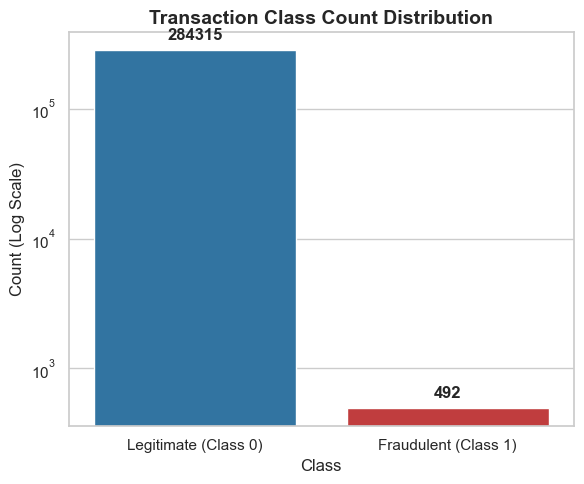

In [13]:
# Visualizing Class Imbalance
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(x='Class', hue='Class', data=df, palette={0: '#1f77b4', 1: '#d62728', '0': '#1f77b4', '1': '#d62728'}, legend=False, ax=ax)
ax.set_title('Transaction Class Count Distribution', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Legitimate (Class 0)', 'Fraudulent (Class 1)'])
ax.set_ylabel('Count (Log Scale)')
ax.set_yscale('log')  # Log scale makes the minority class visible
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


### Implications for Modeling:

- **Why is it imbalanced?**: Credit card fraud is naturally rare; legitimate transactions dominate transaction volume.
- **Why accuracy fails**: Predicting "legitimate" (Class 0) for every transaction yields 99.827% accuracy but catches 0% of fraud. Accuracy is a misleading metric here.
- **Relevant Metrics**: Downstream models should focus on **Precision** (minimizing false positives/customer friction), **Recall** (catching maximum fraud), and **PR-AUC**. PR-AUC is more informative than ROC-AUC here because ROC-AUC is heavily inflated by the massive volume of True Negatives.

## 6. Transaction Amount Analysis
Analyzing the distribution of the transaction amount feature.

In [14]:
# Summary stats for Amount by Class
print('Summary Stats for Transaction Amount by Class:')
df.groupby('Class')['Amount'].describe()


Summary Stats for Transaction Amount by Class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


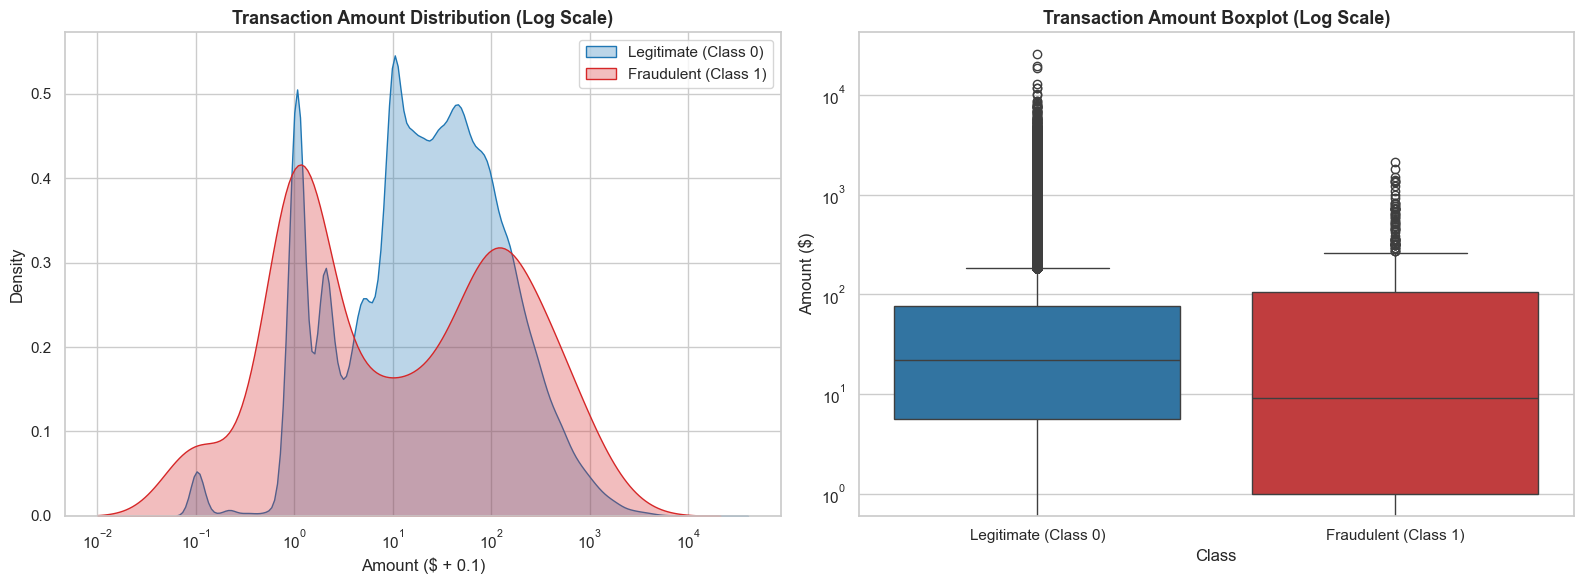

In [15]:
# Visualize distributions and boxplots of Amount
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: KDE plot comparing distributions (using log scale for x-axis due to extreme outliers)
sns.kdeplot(df[df['Class'] == 0]['Amount'] + 0.1, label='Legitimate (Class 0)', log_scale=True, color='#1f77b4', fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(df[df['Class'] == 1]['Amount'] + 0.1, label='Fraudulent (Class 1)', log_scale=True, color='#d62728', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($ + 0.1)')
axes[0].legend()

# Plot 2: Boxplot comparing Class 0 vs Class 1 (using log scale for y-axis)
sns.boxplot(x='Class', y='Amount', hue='Class', data=df, palette={0: '#1f77b4', 1: '#d62728', '0': '#1f77b4', '1': '#d62728'}, legend=False, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Legitimate (Class 0)', 'Fraudulent (Class 1)'])
axes[1].set_title('Transaction Amount Boxplot (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()


In [16]:
# Calculate skewness
print(f'Skewness of Amount in overall dataset: {df["Amount"].skew():.2f}')
print(f'Skewness of Amount in legitimate transactions: {df[df["Class"] == 0]["Amount"].skew():.2f}')
print(f'Skewness of Amount in fraudulent transactions: {df[df["Class"] == 1]["Amount"].skew():.2f}')


Skewness of Amount in overall dataset: 16.98
Skewness of Amount in legitimate transactions: 17.00
Skewness of Amount in fraudulent transactions: 3.75


### Outliers and Scaling Decisions:

- **Outlier Treatment**: Do **not** remove outliers. In fraud detection, fraudulent transactions are often extreme outliers. Dropping them removes the primary target signal we want to learn.
- **Why RobustScaler?**: Standard scaling uses the mean and variance, which are heavily distorted by extreme outliers. MinMaxScaler maps features to [0, 1] but compresses normal transactions to a narrow band close to 0. `RobustScaler` subtracts the median and scales by the IQR, centering the data and scaling it without being affected by extreme outliers.

## 7. Transaction Time Analysis
Analyzing temporal density patterns by mapping elapsed seconds to cyclic hour-of-day.

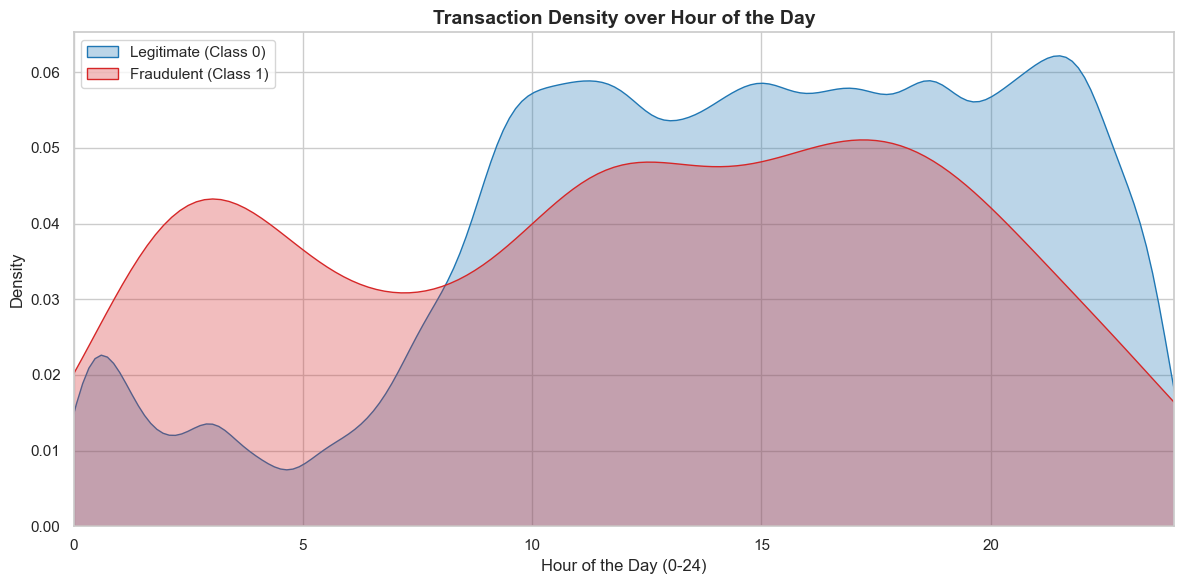

In [17]:
# Convert Time in seconds to Hour of the day (0 to 24 hours)
df['Hour'] = (df['Time'] / 3600) % 24

# Plot Time distributions
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Legitimate (Class 0)', color='#1f77b4', fill=True, alpha=0.3, ax=ax)
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraudulent (Class 1)', color='#d62728', fill=True, alpha=0.3, ax=ax)
ax.set_title('Transaction Density over Hour of the Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of the Day (0-24)')
ax.set_ylabel('Density')
ax.set_xlim(0, 24)
ax.legend()
plt.tight_layout()
plt.show()


### Observations:
- Legitimate transactions show a cyclic diurnal pattern, dropping significantly during sleeping hours (0-6 AM) and peaking during the day.
- Fraudulent transactions are flatter throughout the day and night. They persist during the night when legitimate transaction volume is low, suggesting that the relative risk of fraud is higher during off-peak hours.

## 8. Feature Selection via Kolmogorov-Smirnov Test
Finding the 5 most discriminative features using the non-parametric **Kolmogorov-Smirnov (KS) test**.

### Rationale:
The two-sample KS test evaluates the distance between the cumulative distribution functions (CDFs) of two classes. A KS statistic close to 1.0 indicates that the feature distributions for fraud and legitimate transactions are highly separated. This test is non-parametric and doesn't assume normally distributed features.

In [18]:
from scipy.stats import ks_2samp

# List of features to evaluate (excluding Class and Hour which is a derived column)
features_to_test = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount']

ks_stats = {}
for col in features_to_test:
    fraud = df[df['Class'] == 1][col]
    legit = df[df['Class'] == 0][col]
    d_stat, p_val = ks_2samp(fraud, legit)
    ks_stats[col] = (d_stat, p_val)

# Sort features by KS statistic in descending order
sorted_ks = sorted(ks_stats.items(), key=lambda x: x[1][0], reverse=True)
print('Top 10 features sorted by Kolmogorov-Smirnov statistic:')
print(f'{"Feature":<8} | {"KS Statistic (D)":<16} | {"p-value":<10}')
print('-'*43)
for feat, (d_stat, p_val) in sorted_ks[:10]:
    print(f'{feat:<8} | {d_stat:<16.4f} | {p_val:<10.3e}')


Top 10 features sorted by Kolmogorov-Smirnov statistic:
Feature  | KS Statistic (D) | p-value   
-------------------------------------------
V14      | 0.8428           | 0.000e+00 
V10      | 0.8043           | 0.000e+00 
V12      | 0.7839           | 8.607e-321
V4       | 0.7664           | 2.041e-302
V11      | 0.7561           | 4.348e-292
V17      | 0.7452           | 1.387e-281
V3       | 0.7037           | 9.928e-245
V16      | 0.6865           | 9.367e-231
V7       | 0.6606           | 6.777e-211
V2       | 0.6332           | 2.164e-191


In [19]:
# Get top 5 features
top_5_features = [feat for feat, _ in sorted_ks[:5]]
print(f'Top 5 most discriminative features selected: {top_5_features}')


Top 5 most discriminative features selected: ['V14', 'V10', 'V12', 'V4', 'V11']


### Visualizing the Top 5 Discriminative Features

We plot the Kernel Density Estimate (KDE) and Boxplot for each of the top 5 selected features to visually confirm their separation between Class 0 (legitimate) and Class 1 (fraud).


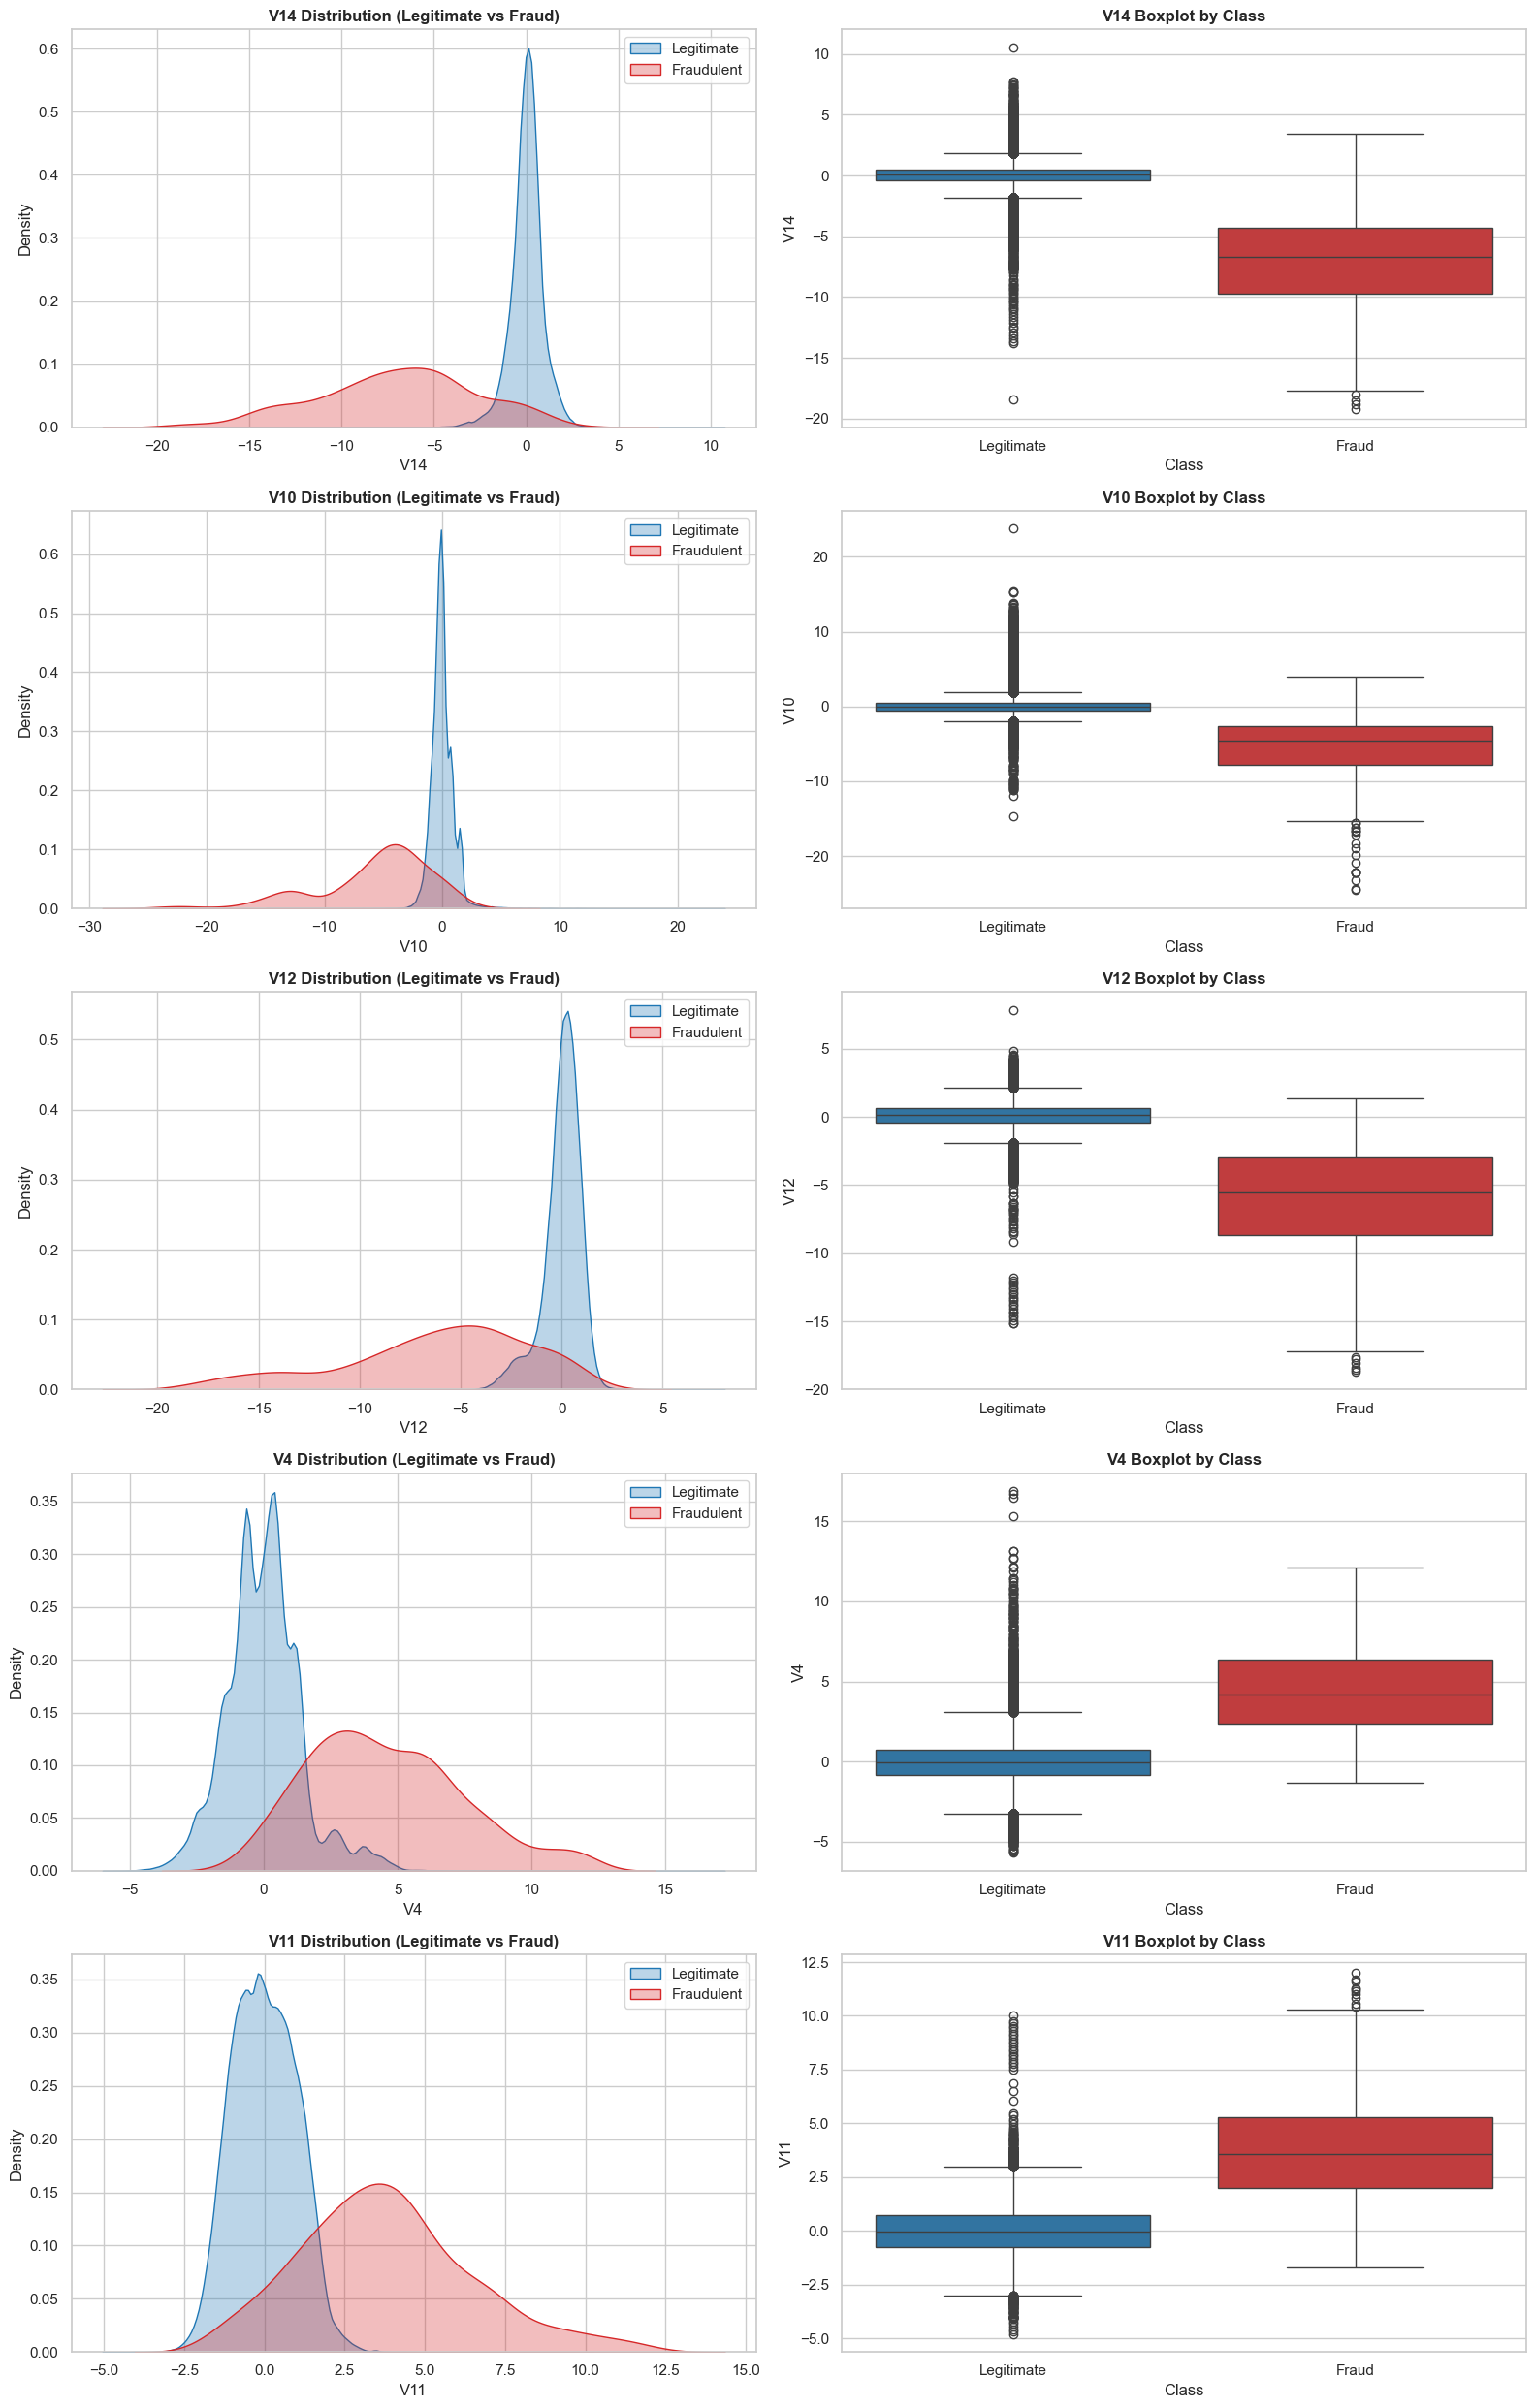

In [20]:
fig, axes = plt.subplots(5, 2, figsize=(16, 25))

for idx, feat in enumerate(top_5_features):
    # Plot 1: KDE plot (Distribution)
    sns.kdeplot(df[df['Class'] == 0][feat], label='Legitimate', color='#1f77b4', fill=True, alpha=0.3, ax=axes[idx, 0])
    sns.kdeplot(df[df['Class'] == 1][feat], label='Fraudulent', color='#d62728', fill=True, alpha=0.3, ax=axes[idx, 0])
    axes[idx, 0].set_title(f'{feat} Distribution (Legitimate vs Fraud)', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(feat)
    axes[idx, 0].legend()
    
    # Plot 2: Boxplot
    sns.boxplot(x='Class', y=feat, hue='Class', data=df, palette={0: '#1f77b4', 1: '#d62728', '0': '#1f77b4', '1': '#d62728'}, legend=False, ax=axes[idx, 1])
    axes[idx, 1].set_xticklabels(['Legitimate', 'Fraud'])
    axes[idx, 1].set_title(f'{feat} Boxplot by Class', fontsize=12, fontweight='bold')
    axes[idx, 1].set_ylabel(feat)

plt.tight_layout()
plt.show()


### Key Observations:
- **V14, V10, V12**: Show negative shifts for fraud. Legitimate transactions cluster closely around 0, whereas fraud values are heavily negative.
- **V4, V11**: Show positive shifts for fraud, centering around 3-6 while legitimate transactions center near 0.

## 9. Correlation Analysis
Checking linear correlations between features and the target.

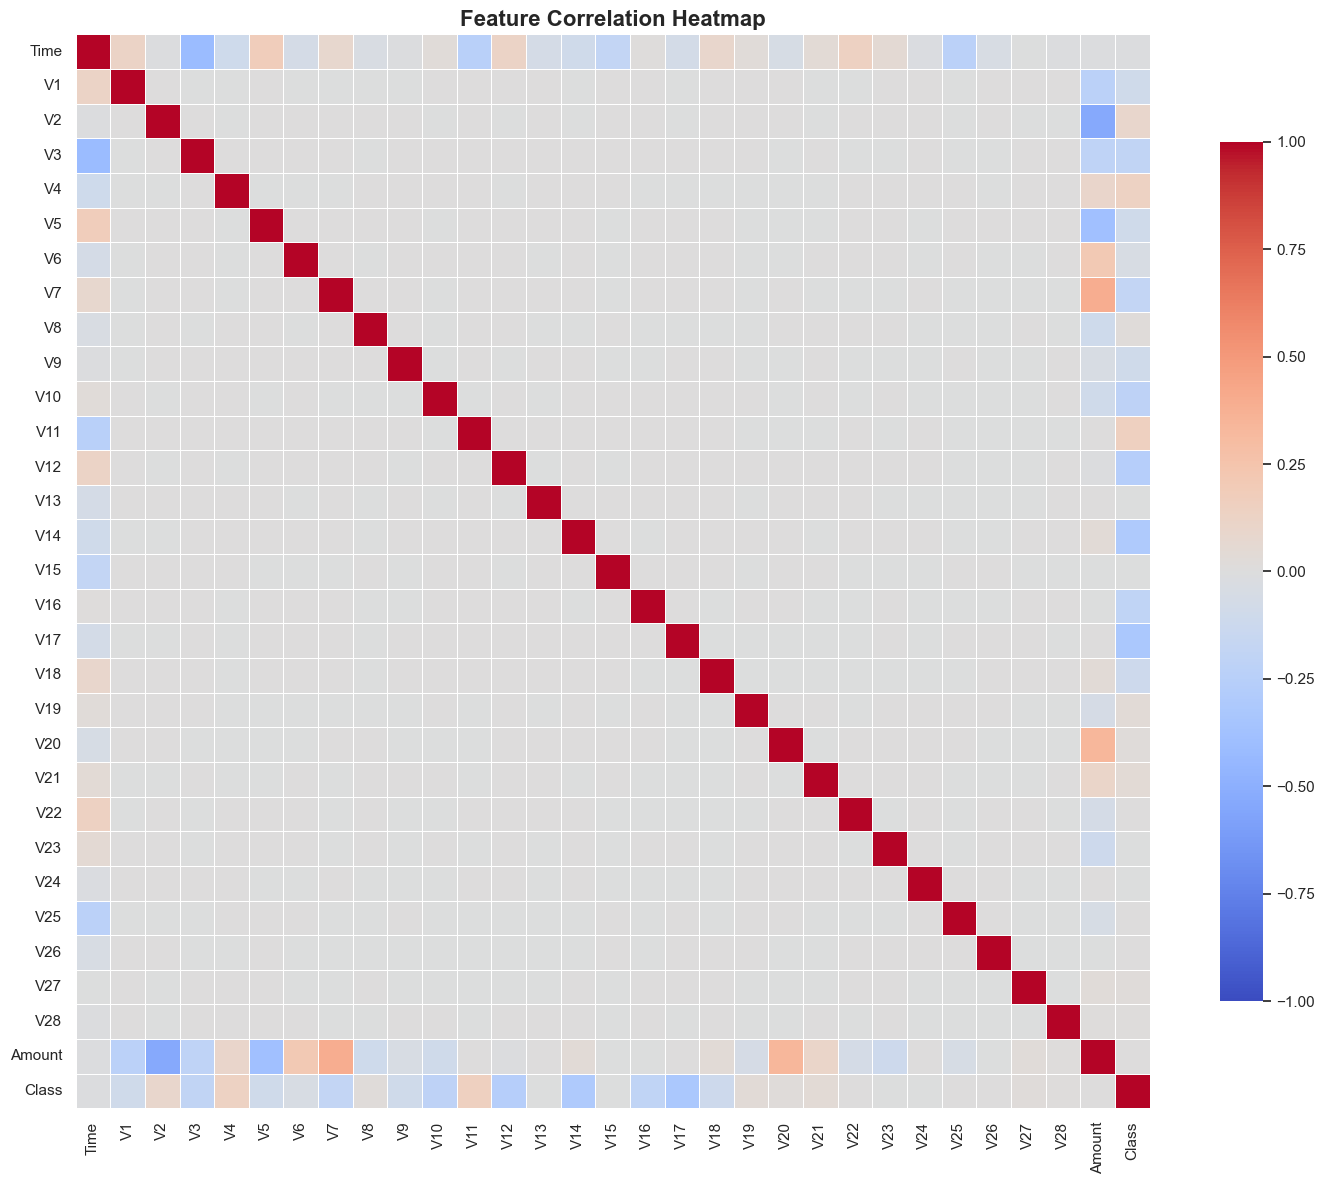

In [21]:
# Compute correlation matrix
corr_matrix = df.drop(columns=['Hour']).corr()

# Plot correlation heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [22]:
# Display features most correlated (positively and negatively) with Class
class_corrs = corr_matrix['Class'].sort_values(ascending=False)
print('Correlation of Features with target variable Class:')
print(class_corrs)


Correlation of Features with target variable Class:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


### Observations:
- **PCA Features Orthogonality**: V1-V28 have exactly 0 correlation with one another. This is mathematically guaranteed by the PCA process.
- **Correlations with target**: The linear correlations mirror the KS test findings. `V17`, `V14`, `V12`, and `V10` show strong negative correlations, whereas `V11` and `V4` show positive correlations.
- **Time & Amount**: Linear correlations with `Class` are near zero. Their relationships with fraud are non-linear.

## 10. Preprocessing Strategy
Summary of preprocessing steps before model training:

1. **Deduplication**: Drop the 1,081 duplicate rows to prevent train-test data leakage.
2. **Imputation**: Include a simple median imputer step for production safety in case missing values appear in future inference records.
3. **Scaling**: Use `RobustScaler` on `Time` and `Amount` to handle heavy skewness and outliers.
4. **PCA Features**: Pass `V1`-`V28` through unchanged (`passthrough`) as they are already standardized by PCA.

## 11. Reproducible Preprocessing Pipeline
Implementing a reusable scikit-learn preprocessing pipeline using `ColumnTransformer` and `RobustScaler`.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

def get_preprocessing_pipeline():
    """
    Constructs a reproducible scikit-learn preprocessing pipeline.
    It applies RobustScaler to the 'Time' and 'Amount' features (which are highly skewed
    and contain prominent outliers) and passes the V1-V28 PCA features through unchanged.
    
    Returns:
        sklearn.pipeline.Pipeline: The preprocessing pipeline.
    """
    # Features to scale (non-PCA original features)
    scaled_features = ['Time', 'Amount']
    
    # PCA features to pass through unchanged
    pca_features = [f'V{i}' for i in range(1, 29)]
    
    # Define ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('robust_scaler', RobustScaler(), scaled_features),
            ('pca_passthrough', 'passthrough', pca_features)
        ],
        remainder='drop'  # Drop target 'Class' or other extra columns during feature transformation
    )
    
    # Return inside a pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor)
    ])
    
    return pipeline

# Instantiate the pipeline
preprocessing_pipeline = get_preprocessing_pipeline()
print('Pipeline loaded successfully:')
print(preprocessing_pipeline)


Pipeline loaded successfully:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('robust_scaler',
                                                  RobustScaler(),
                                                  ['Time', 'Amount']),
                                                 ('pca_passthrough',
                                                  'passthrough',
                                                  ['V1', 'V2', 'V3', 'V4', 'V5',
                                                   'V6', 'V7', 'V8', 'V9',
                                                   'V10', 'V11', 'V12', 'V13',
                                                   'V14', 'V15', 'V16', 'V17',
                                                   'V18', 'V19', 'V20', 'V21',
                                                   'V22', 'V23', 'V24', 'V25',
                                                   'V26', 'V27', 'V28'])]))])


In [26]:
# Drop target Class and derived Hour column to isolate features
X = df.drop(columns=['Class', 'Hour'])
y = df['Class']

# Fit and transform the features
X_processed = preprocessing_pipeline.fit_transform(X)

print(f'Input features shape: {X.shape}')
print(f'Processed features shape: {X_processed.shape}')
print(f'Type of processed features: {type(X_processed)}')

# Show sample of processed data as a DataFrame to verify columns
# Order of columns: Time, Amount, V1, V2, ..., V28
feature_names = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]
df_processed = pd.DataFrame(X_processed, columns=feature_names)
print('\nProcessed features sample (first 2 rows):')
df_processed.head(2)


Input features shape: (284807, 30)
Processed features shape: (284807, 30)
Type of processed features: <class 'numpy.ndarray'>

Processed features sample (first 2 rows):


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,-0.994983,1.783274,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,-0.994983,-0.269825,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724


## 12. EDA Summary

### Summary of Findings:
- **Data Quality**: 0 missing values. Found 1,081 duplicate rows (0.38%), which should be dropped prior to modeling.
- **Imbalance**: Legitimate transactions represent 99.827%, fraud represents 0.173%. accuracy is not an appropriate evaluation metric; Precision, Recall, and PR-AUC must be used.
- **Amount & Outliers**: High right-skew. Outliers are critical indicators of fraud and are kept. Scaled using `RobustScaler` to prevent feature distortion.
- **Time Cyclic Trend**: Legitimate volume matches typical day/night patterns. Fraud occurs continuously, raising relative fraud risk at night.
- **Discriminative Features**: V14, V10, V12, V4, and V11 show the cleanest class separation according to Kolmogorov-Smirnov statistics.
- **Pipeline**: Defined a clean scikit-learn preprocessing pipeline ready for downstream training.